# Individual Model Training and Evaluation - Logistic Regression, Random Forest, XGBoost

## Introduction
This notebook is training and evaluating the six individual models used in this phase of the thesis. The notebook is loading the prepared modelling sets from Notebook 07 and is fitting three algorithms on each model set:

- Model 1 + Logistic Regression
- Model 1 + Random Forest
- Model 1 + XGBoost
- Model 2 + Logistic Regression
- Model 2 + Random Forest
- Model 2 + XGBoost

Model 1 is representing the **non-invasive clinical screening model**. Model 2 is representing the **invasive benchmark model**. This notebook is comparing them fairly because both model sets were prepared earlier and are now being reused without any new splitting, scaling, or class balancing.

This notebook is coming before ensemble learning, optimization, and SHAP because the project first needs to understand how the individual base learners perform on their own. These six trained models become the baseline that later notebooks must improve on.

The same locked 10-fold stratified cross-validation object from Notebook 07 is being reused for all six models so the comparison stays consistent. A key caution is also being stated clearly here: the saved training sets were already SMOTEd in Notebook 07, so the cross-validation scores in this notebook may read slightly better than a fold-local SMOTE design. The hold-out test-set metrics remain the main external benchmark inside this notebook.

No new preprocessing is happening here. This notebook is **not** re-splitting data, re-scaling features, or re-applying SMOTE. It is only training, evaluating, saving models, and producing comparison visuals.

## Output Files Produced in This Notebook
| Output File | Purpose |
| --- | --- |
| `models/model1_lr.pkl` | Saved Logistic Regression model for Model 1. |
| `models/model1_rf.pkl` | Saved Random Forest model for Model 1. |
| `models/model1_xgb.pkl` | Saved XGBoost model for Model 1. |
| `models/model2_lr.pkl` | Saved Logistic Regression model for Model 2. |
| `models/model2_rf.pkl` | Saved Random Forest model for Model 2. |
| `models/model2_xgb.pkl` | Saved XGBoost model for Model 2. |
| `cleaned_data/modelling_sets/individual_model_results.csv` | Master results table for all six individual models. |
| `images/individual_models/01-14_*.png` | Confusion matrices, ROC plots, CV plots, and master comparison figures. |


## Section 1 - Imports and Configuration

This section is importing the libraries, resolving the project root, and loading the locked modelling files produced in Notebook 07.


In [58]:
# Importing the modelling libraries is preparing the notebook for training, evaluation, plotting, and artifact export.
from pathlib import Path
import os
import warnings
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "xgboost is required for Notebook 08. Install it in your current notebook environment with "
        "`pip install xgboost` or `conda install -c conda-forge xgboost`, then restart the kernel and run the notebook again."
    ) from exc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TARGET = 'pcos_y_n'

COLORS = {
    'pcos_pos': '#E63946',
    'pcos_neg': '#457B9D',
    'model1': '#2A9D8F',
    'model2': '#E9C46A',
    'lr': '#264653',
    'rf': '#2A9D8F',
    'xgb': '#E76F51',
    'neutral': '#2C3E50',
    'highlight': '#8D5A97'
}


In [59]:
# Resolving the project root and creating the image output folder is keeping the notebook runnable from different working directories.
def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / 'cleaned_data').exists() and (candidate / 'models').exists():
            return candidate
    return current

PROJECT_ROOT = resolve_project_root()
MODELLING_DIR = PROJECT_ROOT / 'cleaned_data' / 'modelling_sets'
MODELS_DIR = PROJECT_ROOT / 'models'
IMAGE_DIR = PROJECT_ROOT / 'images' / 'individual_models'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Created or confirmed: {IMAGE_DIR}")


Created or confirmed: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models


In [60]:
# Loading the prepared modelling sets and feature contracts is using Notebook 07 as the only source of truth for training data.
train1 = pd.read_csv(MODELLING_DIR / 'model1_train.csv')
test1 = pd.read_csv(MODELLING_DIR / 'model1_test.csv')
train2 = pd.read_csv(MODELLING_DIR / 'model2_train.csv')
test2 = pd.read_csv(MODELLING_DIR / 'model2_test.csv')

with open(MODELLING_DIR / 'feature_names_model1.json', encoding='utf-8') as f:
    MODEL1_FEATURES = json.load(f)
with open(MODELLING_DIR / 'feature_names_model2.json', encoding='utf-8') as f:
    MODEL2_FEATURES = json.load(f)

cv = joblib.load(MODELS_DIR / 'cv_strategy.pkl')

assert len(MODEL1_FEATURES) == 19, f"Expected 19 Model 1 features, found {len(MODEL1_FEATURES)}."
assert len(MODEL2_FEATURES) == 15, f"Expected 15 Model 2 features, found {len(MODEL2_FEATURES)}."

print("Model 1 feature list:")
print(MODEL1_FEATURES)
print()
print("Model 2 feature list:")
print(MODEL2_FEATURES)
print()
print("DataFrame shapes:")
print(f"train1: {train1.shape}")
print(f"test1 : {test1.shape}")
print(f"train2: {train2.shape}")
print(f"test2 : {test2.shape}")
print()
print("CV strategy:")
print(cv)
print(f"CV strategy type: {type(cv).__name__}")


Model 1 feature list:
['age_yrs', 'bmi', 'cycle_regularity_binary', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'waist_hip_ratio', 'rbs_mg_dl', 'symptom_burden', 'bmi_category', 'bp_elevated_flag', 'lifestyle_risk']

Model 2 feature list:
['amh_ng_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh_ratio', 'tsh_miu_l', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'beta_hcg_i_miu_ml', 'beta_hcg_ii_miu_ml', 'follicle_no_left', 'follicle_no_right', 'avg_follicle_size_left_mm', 'avg_follicle_size_right_mm', 'endometrium_mm']

DataFrame shapes:
train1: (582, 20)
test1 : (109, 20)
train2: (582, 16)
test2 : (109, 16)

CV strategy:
StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
CV strategy type: StratifiedKFold


In [61]:
# Separating features and target is locking the exact training arrays used by each algorithm.
X1_train = train1[MODEL1_FEATURES].values
y1_train = train1[TARGET].values
X1_test = test1[MODEL1_FEATURES].values
y1_test = test1[TARGET].values

X2_train = train2[MODEL2_FEATURES].values
y2_train = train2[TARGET].values
X2_test = test2[MODEL2_FEATURES].values
y2_test = test2[TARGET].values

shape_table = pd.DataFrame(
    [
        {"set": "X1_train", "rows": X1_train.shape[0], "columns": X1_train.shape[1]},
        {"set": "X1_test", "rows": X1_test.shape[0], "columns": X1_test.shape[1]},
        {"set": "X2_train", "rows": X2_train.shape[0], "columns": X2_train.shape[1]},
        {"set": "X2_test", "rows": X2_test.shape[0], "columns": X2_test.shape[1]},
    ]
)
print(shape_table.to_string(index=False))
print()

class_distribution_table = pd.DataFrame(
    [
        {"set": "y1_train", "no_pcos": int((y1_train == 0).sum()), "pcos": int((y1_train == 1).sum())},
        {"set": "y1_test", "no_pcos": int((y1_test == 0).sum()), "pcos": int((y1_test == 1).sum())},
        {"set": "y2_train", "no_pcos": int((y2_train == 0).sum()), "pcos": int((y2_train == 1).sum())},
        {"set": "y2_test", "no_pcos": int((y2_test == 0).sum()), "pcos": int((y2_test == 1).sum())},
    ]
)
print(class_distribution_table.to_string(index=False))


     set  rows  columns
X1_train   582       19
 X1_test   109       19
X2_train   582       15
 X2_test   109       15

     set  no_pcos  pcos
y1_train      291   291
 y1_test       73    36
y2_train      291   291
 y2_test       73    36


In [62]:
# Defining evaluate_model is keeping the hold-out metric calculation consistent across all six trained models.
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='binary', zero_division=0),
        'auc': roc_auc_score(y_test, y_prob),
    }


In [63]:
# Defining run_cv is keeping the ten-fold cross-validation summary consistent across all algorithms and both model sets.
def run_cv(name, model, X_train, y_train, cv):
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_output = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None,
    )

    fold_scores = pd.DataFrame({
        'fold': range(1, len(cv_output['test_accuracy']) + 1),
        'accuracy': cv_output['test_accuracy'],
        'precision': cv_output['test_precision'],
        'recall': cv_output['test_recall'],
        'f1': cv_output['test_f1'],
        'roc_auc': cv_output['test_roc_auc'],
    })

    summary_df = pd.DataFrame({
        'metric': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        'mean': [
            fold_scores['accuracy'].mean(),
            fold_scores['precision'].mean(),
            fold_scores['recall'].mean(),
            fold_scores['f1'].mean(),
            fold_scores['roc_auc'].mean(),
        ],
        'std': [
            fold_scores['accuracy'].std(),
            fold_scores['precision'].std(),
            fold_scores['recall'].std(),
            fold_scores['f1'].std(),
            fold_scores['roc_auc'].std(),
        ],
    }).round(4)

    print(f"Cross-validation summary - {name}")
    print(summary_df.to_string(index=False))

    return {
        'model': name,
        'summary_table': summary_df,
        'fold_scores': fold_scores,
        'accuracy_mean': summary_df.loc[summary_df['metric'] == 'accuracy', 'mean'].iloc[0],
        'accuracy_std': summary_df.loc[summary_df['metric'] == 'accuracy', 'std'].iloc[0],
        'precision_mean': summary_df.loc[summary_df['metric'] == 'precision', 'mean'].iloc[0],
        'precision_std': summary_df.loc[summary_df['metric'] == 'precision', 'std'].iloc[0],
        'recall_mean': summary_df.loc[summary_df['metric'] == 'recall', 'mean'].iloc[0],
        'recall_std': summary_df.loc[summary_df['metric'] == 'recall', 'std'].iloc[0],
        'f1_mean': summary_df.loc[summary_df['metric'] == 'f1', 'mean'].iloc[0],
        'f1_std': summary_df.loc[summary_df['metric'] == 'f1', 'std'].iloc[0],
        'roc_auc_mean': summary_df.loc[summary_df['metric'] == 'roc_auc', 'mean'].iloc[0],
        'roc_auc_std': summary_df.loc[summary_df['metric'] == 'roc_auc', 'std'].iloc[0],
    }


## Model 1: Logistic Regression

Logistic Regression is serving as the interpretable linear baseline for Model 1. It is assuming a linear decision boundary between PCOS-negative and PCOS-positive cases in the non-invasive feature space. If this model performs well, it suggests the routine screening features already separate the classes in a simple way. If it underperforms the tree-based models, that suggests non-linear feature interactions matter.


In [64]:
# Defining and training Model 1 Logistic Regression is fitting the individual model on the locked training set from Notebook 07.
lr1 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    solver='lbfgs'
)
lr1.fit(X1_train, y1_train)
print("lr1 trained successfully.")


lr1 trained successfully.


In [65]:
# Running cross-validation for Model 1 Logistic Regression is estimating training stability with the locked 10-fold strategy.
cv_results_m1_lr = run_cv("Model 1 - Logistic Regression", lr1, X1_train, y1_train, cv)


Cross-validation summary - Model 1 - Logistic Regression
   metric   mean    std
 accuracy 0.8281 0.0501
precision 0.8386 0.0875
   recall 0.8248 0.0337
       f1 0.8292 0.0438
  roc_auc 0.8947 0.0312


In [66]:
# Evaluating Model 1 Logistic Regression on the hold-out test set is producing the final test metrics used in the comparison tables.
y1_pred_lr = lr1.predict(X1_test)
y1_proba_lr = lr1.predict_proba(X1_test)[:, 1]
results_m1_lr = evaluate_model("Model 1 - LR", lr1, X1_test, y1_test)

results_m1_lr_df = pd.DataFrame([results_m1_lr]).round(4)
print(results_m1_lr_df.to_string(index=False))


       model  accuracy  precision  recall     f1    auc
Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839


In [67]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m1_lr['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m1_lr['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m1_lr['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m1_lr['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m1_lr['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 Logistic Regression is giving a recall of **{results_m1_lr['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8349**. This is the share of all test cases the model got right.
- Precision: **0.7368**. This shows how often a positive prediction was actually correct.
- Recall: **0.7778**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7568**. This is the balance between precision and recall.
- AUC: **0.8839**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 Logistic Regression is giving a recall of **77.8%**, so it is catching about that share of PCOS-positive cases in the test set.

In [68]:
# Printing the confusion matrix table for Model 1 Logistic Regression is documenting the exact counts behind the heatmap.
cm_m1_lr = confusion_matrix(y1_test, y1_pred_lr)
cm_m1_lr_df = pd.DataFrame(
    cm_m1_lr,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 Logistic Regression:")
print(cm_m1_lr_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m1_lr[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m1_lr[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m1_lr[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m1_lr[0, 0]}")


Confusion Matrix - Model 1 Logistic Regression:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  63               10
Actual: PCOS                      8               28

True Positives  (caught PCOS cases) : 28
False Negatives (missed PCOS cases) : 8
False Positives (false alarms)      : 10
True Negatives  (correctly cleared) : 63


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\01_model1_lr_confusion_matrix.png


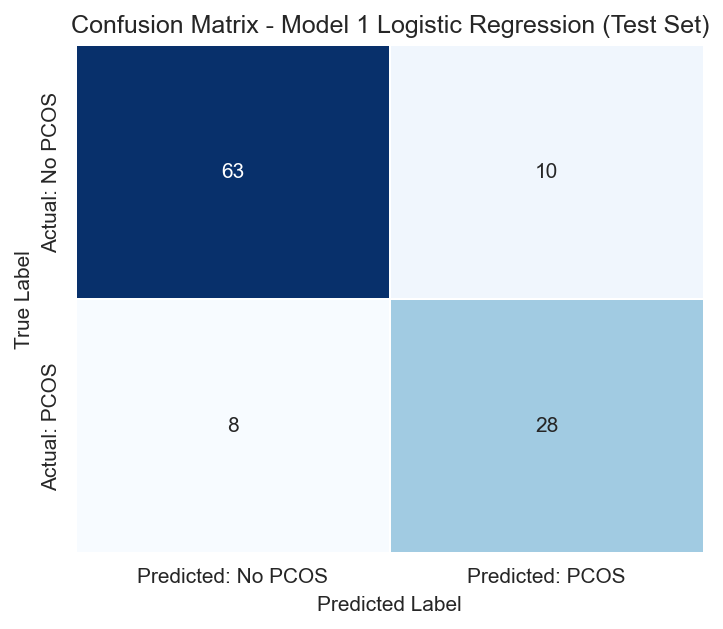

In [69]:
# Plotting the confusion matrix for Model 1 Logistic Regression is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m1_lr_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 Logistic Regression (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "01_model1_lr_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [70]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m1_lr[1, 1])
fn = int(cm_m1_lr[1, 0])
fp = int(cm_m1_lr[0, 1])
tn = int(cm_m1_lr[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 Logistic Regression, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **28**. These are PCOS cases the model caught correctly.
- False negatives: **8**. These are real PCOS cases the model missed.
- False positives: **10**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **63**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 1 Logistic Regression, the most important number to watch is the false-negative count of **8**, because missed PCOS cases matter more in a screening study.

In [71]:
# Saving Model 1 Logistic Regression is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model1_lr.pkl"
joblib.dump(lr1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_lr.pkl


## Model 1: Random Forest

Random Forest is serving as the main tree-based ensemble baseline for Model 1. It is capturing non-linear interactions between symptoms, blood pressure, glucose, and body measures. This matters because PCOS screening patterns are often built from combinations of features rather than one linear shift. It is also producing native feature importance values that can later be compared with SHAP.


In [72]:
# Defining and training Model 1 Random Forest is fitting the individual model on the locked training set from Notebook 07.
rf1 = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf1.fit(X1_train, y1_train)
print("rf1 trained successfully.")


rf1 trained successfully.


In [73]:
# Running cross-validation for Model 1 Random Forest is estimating training stability with the locked 10-fold strategy.
cv_results_m1_rf = run_cv("Model 1 - Random Forest", rf1, X1_train, y1_train, cv)


Cross-validation summary - Model 1 - Random Forest
   metric   mean    std
 accuracy 0.8866 0.0246
precision 0.8921 0.0564
   recall 0.8864 0.0543
       f1 0.8867 0.0238
  roc_auc 0.9538 0.0175


In [74]:
# Evaluating Model 1 Random Forest on the hold-out test set is producing the final test metrics used in the comparison tables.
y1_pred_rf = rf1.predict(X1_test)
y1_proba_rf = rf1.predict_proba(X1_test)[:, 1]
results_m1_rf = evaluate_model("Model 1 - RF", rf1, X1_test, y1_test)

results_m1_rf_df = pd.DataFrame([results_m1_rf]).round(4)
print(results_m1_rf_df.to_string(index=False))


       model  accuracy  precision  recall     f1    auc
Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098


In [75]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m1_rf['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m1_rf['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m1_rf['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m1_rf['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m1_rf['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 Random Forest is giving a recall of **{results_m1_rf['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8532**. This is the share of all test cases the model got right.
- Precision: **0.8125**. This shows how often a positive prediction was actually correct.
- Recall: **0.7222**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7647**. This is the balance between precision and recall.
- AUC: **0.9098**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 Random Forest is giving a recall of **72.2%**, so it is catching about that share of PCOS-positive cases in the test set.

In [76]:
# Printing the confusion matrix table for Model 1 Random Forest is documenting the exact counts behind the heatmap.
cm_m1_rf = confusion_matrix(y1_test, y1_pred_rf)
cm_m1_rf_df = pd.DataFrame(
    cm_m1_rf,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 Random Forest:")
print(cm_m1_rf_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m1_rf[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m1_rf[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m1_rf[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m1_rf[0, 0]}")


Confusion Matrix - Model 1 Random Forest:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  67                6
Actual: PCOS                     10               26

True Positives  (caught PCOS cases) : 26
False Negatives (missed PCOS cases) : 10
False Positives (false alarms)      : 6
True Negatives  (correctly cleared) : 67


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\02_model1_rf_confusion_matrix.png


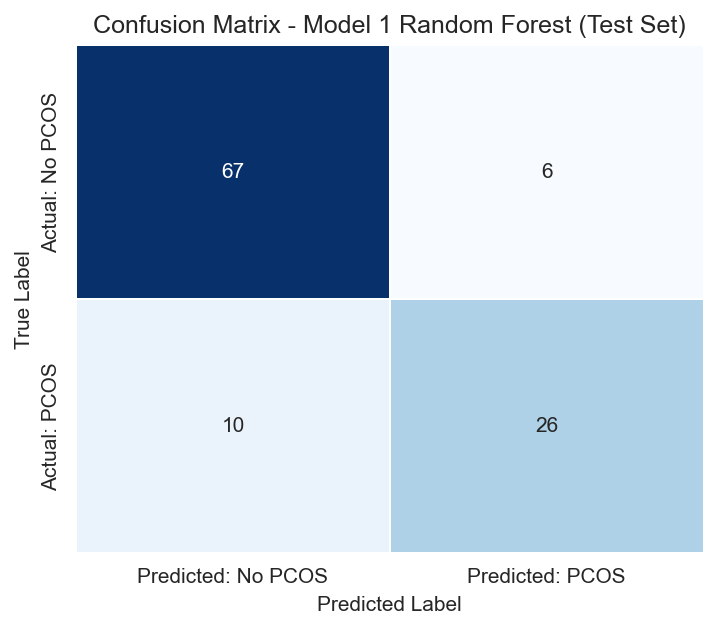

In [77]:
# Plotting the confusion matrix for Model 1 Random Forest is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m1_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 Random Forest (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "02_model1_rf_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [78]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m1_rf[1, 1])
fn = int(cm_m1_rf[1, 0])
fp = int(cm_m1_rf[0, 1])
tn = int(cm_m1_rf[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 Random Forest, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **26**. These are PCOS cases the model caught correctly.
- False negatives: **10**. These are real PCOS cases the model missed.
- False positives: **6**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **67**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 1 Random Forest, the most important number to watch is the false-negative count of **10**, because missed PCOS cases matter more in a screening study.

In [79]:
# Printing the ranked feature importances for Model 1 Random Forest is giving an interpretable reference before later SHAP work.
fi_df = pd.DataFrame({
    "feature": MODEL1_FEATURES,
    "importance": rf1.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Model 1 Random Forest - Feature Importances (ranked):")
print(fi_df.to_string(index=False))


Model 1 Random Forest - Feature Importances (ranked):
                feature  importance
         symptom_burden      0.2000
      cycle_length_days      0.0908
        weight_gain_y_n      0.0803
     skin_darkening_y_n      0.0692
        waist_hip_ratio      0.0663
                age_yrs      0.0654
                    bmi      0.0612
        hair_growth_y_n      0.0581
cycle_regularity_binary      0.0500
              rbs_mg_dl      0.0490
          fast_food_y_n      0.0358
         lifestyle_risk      0.0329
            pimples_y_n      0.0304
           bmi_category      0.0293
       systolic_bp_mmhg      0.0223
          hair_loss_y_n      0.0175
   regular_exercise_y_n      0.0164
      diastolic_bp_mmhg      0.0138
       bp_elevated_flag      0.0114


In [80]:
# Writing the feature-importance insight is making the ranking table easier to explain in a meeting.
top_features = fi_df.head(3)['feature'].tolist()
feature_markdown = "\n".join([
    "### Feature Importance Insight",
    "",
    f"- The top features in this Random Forest model are **{top_features[0]}**, **{top_features[1]}**, and **{top_features[2]}**.",
    "- Higher feature importance means the model is using that feature more often when it builds its decision trees.",
    "- This is only a quick model-based ranking. The stronger explanation step will come later with SHAP.",
    "",
    "**Simple meaning:** These top features are the ones this Random Forest model is leaning on the most when it decides whether a case looks like PCOS.",
])
display(Markdown(feature_markdown))


### Feature Importance Insight

- The top features in this Random Forest model are **symptom_burden**, **cycle_length_days**, and **weight_gain_y_n**.
- Higher feature importance means the model is using that feature more often when it builds its decision trees.
- This is only a quick model-based ranking. The stronger explanation step will come later with SHAP.

**Simple meaning:** These top features are the ones this Random Forest model is leaning on the most when it decides whether a case looks like PCOS.

In [81]:
# Saving Model 1 Random Forest is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model1_rf.pkl"
joblib.dump(rf1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_rf.pkl


## Model 1: XGBoost

XGBoost is serving as the strongest expected individual learner for Model 1. It is building trees one after another, with each new tree correcting earlier errors. This is often powerful for tabular clinical data, especially when feature interactions are uneven or non-linear. The scale_pos_weight value is still being printed, even though the Notebook 07 training set was already balanced with SMOTE.


In [82]:
# Computing scale_pos_weight is documenting the effective class weighting being passed into Model 1 XGBoost.
neg_count = int((y1_train == 0).sum())
pos_count = int((y1_train == 1).sum())
spw1 = neg_count / pos_count

print(f"Negative class count : {neg_count}")
print(f"Positive class count : {pos_count}")
print(f"scale_pos_weight     : {spw1:.4f}")
print("Note: the value is expected to be close to 1.0 because Notebook 07 already balanced the training set with SMOTE.")


Negative class count : 291
Positive class count : 291
scale_pos_weight     : 1.0000
Note: the value is expected to be close to 1.0 because Notebook 07 already balanced the training set with SMOTE.


In [83]:
# Defining and training Model 1 XGBoost is fitting the individual model on the locked training set from Notebook 07.
xgb1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb1.fit(X1_train, y1_train)
print("xgb1 trained successfully.")


xgb1 trained successfully.


In [84]:
# Running cross-validation for Model 1 XGBoost is estimating training stability with the locked 10-fold strategy.
cv_results_m1_xgb = run_cv("Model 1 - XGBoost", xgb1, X1_train, y1_train, cv)


Cross-validation summary - Model 1 - XGBoost
   metric   mean    std
 accuracy 0.8661 0.0355
precision 0.8858 0.0661
   recall 0.8489 0.0692
       f1 0.8635 0.0353
  roc_auc 0.9411 0.0174


In [85]:
# Evaluating Model 1 XGBoost on the hold-out test set is producing the final test metrics used in the comparison tables.
y1_pred_xgb = xgb1.predict(X1_test)
y1_proba_xgb = xgb1.predict_proba(X1_test)[:, 1]
results_m1_xgb = evaluate_model("Model 1 - XGB", xgb1, X1_test, y1_test)

results_m1_xgb_df = pd.DataFrame([results_m1_xgb]).round(4)
print(results_m1_xgb_df.to_string(index=False))


        model  accuracy  precision  recall     f1    auc
Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026


In [86]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m1_xgb['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m1_xgb['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m1_xgb['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m1_xgb['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m1_xgb['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 1 XGBoost is giving a recall of **{results_m1_xgb['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8716**. This is the share of all test cases the model got right.
- Precision: **0.8438**. This shows how often a positive prediction was actually correct.
- Recall: **0.7500**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7941**. This is the balance between precision and recall.
- AUC: **0.9026**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 1 XGBoost is giving a recall of **75.0%**, so it is catching about that share of PCOS-positive cases in the test set.

In [87]:
# Printing the confusion matrix table for Model 1 XGBoost is documenting the exact counts behind the heatmap.
cm_m1_xgb = confusion_matrix(y1_test, y1_pred_xgb)
cm_m1_xgb_df = pd.DataFrame(
    cm_m1_xgb,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 1 XGBoost:")
print(cm_m1_xgb_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m1_xgb[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m1_xgb[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m1_xgb[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m1_xgb[0, 0]}")


Confusion Matrix - Model 1 XGBoost:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  68                5
Actual: PCOS                      9               27

True Positives  (caught PCOS cases) : 27
False Negatives (missed PCOS cases) : 9
False Positives (false alarms)      : 5
True Negatives  (correctly cleared) : 68


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\03_model1_xgb_confusion_matrix.png


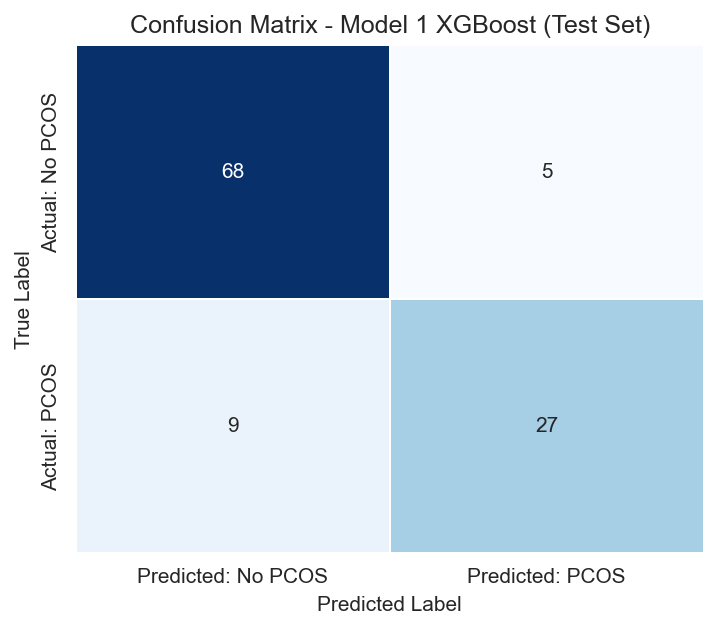

In [88]:
# Plotting the confusion matrix for Model 1 XGBoost is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m1_xgb_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 1 XGBoost (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "03_model1_xgb_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [89]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m1_xgb[1, 1])
fn = int(cm_m1_xgb[1, 0])
fp = int(cm_m1_xgb[0, 1])
tn = int(cm_m1_xgb[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 1 XGBoost, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **27**. These are PCOS cases the model caught correctly.
- False negatives: **9**. These are real PCOS cases the model missed.
- False positives: **5**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **68**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 1 XGBoost, the most important number to watch is the false-negative count of **9**, because missed PCOS cases matter more in a screening study.

In [90]:
# Saving Model 1 XGBoost is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model1_xgb.pkl"
joblib.dump(xgb1, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_xgb.pkl


## Model 1: Algorithm Comparison

This section is comparing the three individual algorithms inside Model 1 before moving to the next model set. The table and plots below are defining the single-model baseline for this feature contract.


In [91]:
# Printing the Model 1 comparison table is showing the final hold-out test metrics side by side.
m1_results = pd.DataFrame([results_m1_lr, results_m1_rf, results_m1_xgb])
m1_results["algorithm"] = ["LR", "RF", "XGB"]
m1_results = m1_results.set_index("model").round(4)

print("MODEL 1 - Algorithm Comparison (Test Set)")
print("=" * 70)
print(m1_results.to_string())
print()
print(f"Best Recall : {m1_results['recall'].idxmax()} ({m1_results['recall'].max():.4f})")
print(f"Best AUC    : {m1_results['auc'].idxmax()} ({m1_results['auc'].max():.4f})")
print(f"Best F1     : {m1_results['f1'].idxmax()} ({m1_results['f1'].max():.4f})")


MODEL 1 - Algorithm Comparison (Test Set)
               accuracy  precision  recall     f1    auc algorithm
model                                                             
Model 1 - LR     0.8349     0.7368  0.7778 0.7568 0.8839        LR
Model 1 - RF     0.8532     0.8125  0.7222 0.7647 0.9098        RF
Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026       XGB

Best Recall : Model 1 - LR (0.7778)
Best AUC    : Model 1 - RF (0.9098)
Best F1     : Model 1 - XGB (0.7941)


In [92]:
# Writing the Model 1 comparison insight is turning the metric table into a simple summary.
best_auc_row = m1_results.reset_index().sort_values("auc", ascending=False).iloc[0]
best_recall_row = m1_results.reset_index().sort_values("recall", ascending=False).iloc[0]
best_f1_row = m1_results.reset_index().sort_values("f1", ascending=False).iloc[0]

comparison_markdown = "\n".join([
    "### Comparison Insight",
    "",
    f"- The best AUC in Model 1 is coming from **{best_auc_row['algorithm']}** at **{best_auc_row['auc']:.4f}**.",
    f"- The best recall in Model 1 is coming from **{best_recall_row['algorithm']}** at **{best_recall_row['recall']:.4f}**.",
    f"- The best F1 score in Model 1 is coming from **{best_f1_row['algorithm']}** at **{best_f1_row['f1']:.4f}**.",
    "",
    f"**Simple meaning:** Inside Model 1, this table is showing which algorithm is best at overall separation, which one catches the most PCOS cases, and which one gives the best balance between missing cases and raising false alarms.",
])
display(Markdown(comparison_markdown))


### Comparison Insight

- The best AUC in Model 1 is coming from **RF** at **0.9098**.
- The best recall in Model 1 is coming from **LR** at **0.7778**.
- The best F1 score in Model 1 is coming from **XGB** at **0.7941**.

**Simple meaning:** Inside Model 1, this table is showing which algorithm is best at overall separation, which one catches the most PCOS cases, and which one gives the best balance between missing cases and raising false alarms.

In [93]:
# Printing the ROC summary table is documenting the exact AUC values used before plotting the Model 1 ROC curves.
m1_roc_table = (
    m1_results.reset_index()[["model", "algorithm", "auc"]]
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)
print(m1_roc_table.to_string(index=False))


        model algorithm    auc
 Model 1 - RF        RF 0.9098
Model 1 - XGB       XGB 0.9026
 Model 1 - LR        LR 0.8839


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\07_model1_roc_curves_all_algorithms.png


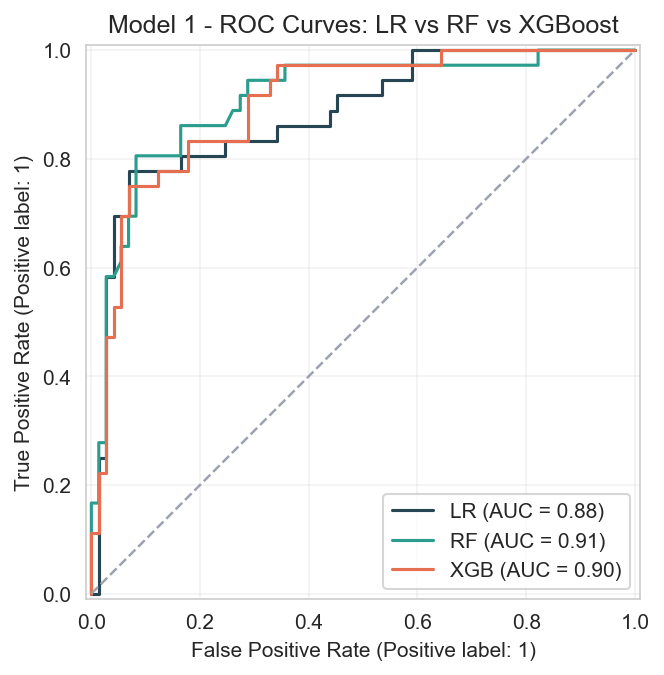

In [94]:
# Plotting the Model 1 ROC curves is comparing discrimination across the three individual algorithms on the same test set.
fig, ax = plt.subplots(figsize=(6.6, 4.8))
RocCurveDisplay.from_estimator(lr1, X1_test, y1_test, ax=ax, name="LR", color=COLORS["lr"])
RocCurveDisplay.from_estimator(rf1, X1_test, y1_test, ax=ax, name="RF", color=COLORS["rf"])
RocCurveDisplay.from_estimator(xgb1, X1_test, y1_test, ax=ax, name="XGB", color=COLORS["xgb"])
ax.plot([0, 1], [0, 1], linestyle="--", color="#9CA3AF", linewidth=1.2)
ax.set_title("Model 1 - ROC Curves: LR vs RF vs XGBoost")
ax.grid(alpha=0.25)

output_path = IMAGE_DIR / "07_model1_roc_curves_all_algorithms.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [95]:
# Writing the ROC insight is explaining what the curve comparison means in simple terms.
best_roc_row = m1_roc_table.iloc[0]
roc_markdown = "\n".join([
    "### ROC Insight",
    "",
    f"- The top ROC result in Model 1 is **{best_roc_row['algorithm']}** with an AUC of **{best_roc_row['auc']:.4f}**.",
    "- The curve that stays closer to the top-left corner is doing a better job of separating positive and negative cases.",
    "- The diagonal line is the no-skill line. A good model should stay above it.",
    "",
    f"**Simple meaning:** In Model 1, the algorithm with the highest AUC is giving the cleanest overall separation between PCOS and non-PCOS cases.",
])
display(Markdown(roc_markdown))


### ROC Insight

- The top ROC result in Model 1 is **RF** with an AUC of **0.9098**.
- The curve that stays closer to the top-left corner is doing a better job of separating positive and negative cases.
- The diagonal line is the no-skill line. A good model should stay above it.

**Simple meaning:** In Model 1, the algorithm with the highest AUC is giving the cleanest overall separation between PCOS and non-PCOS cases.

In [96]:
# Printing the raw fold AUC table is documenting the exact cross-validation values used in the Model 1 CV distribution plot.
m1_cv_auc_df = pd.DataFrame({
    "fold": range(1, len(cv_results_m1_lr["fold_scores"]) + 1),
    "LR": cv_results_m1_lr["fold_scores"]["roc_auc"].values,
    "RF": cv_results_m1_rf["fold_scores"]["roc_auc"].values,
    "XGB": cv_results_m1_xgb["fold_scores"]["roc_auc"].values,
})
print(m1_cv_auc_df.to_string(index=False))


 fold     LR     RF    XGB
    1 0.9207 0.9655 0.9310
    2 0.8448 0.9534 0.9425
    3 0.9298 0.9203 0.9049
    4 0.8680 0.9400 0.9227
    5 0.8716 0.9477 0.9477
    6 0.9358 0.9727 0.9596
    7 0.9120 0.9441 0.9512
    8 0.8847 0.9744 0.9572
    9 0.8680 0.9471 0.9382
   10 0.9120 0.9727 0.9560


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\09_model1_cv_score_distributions.png


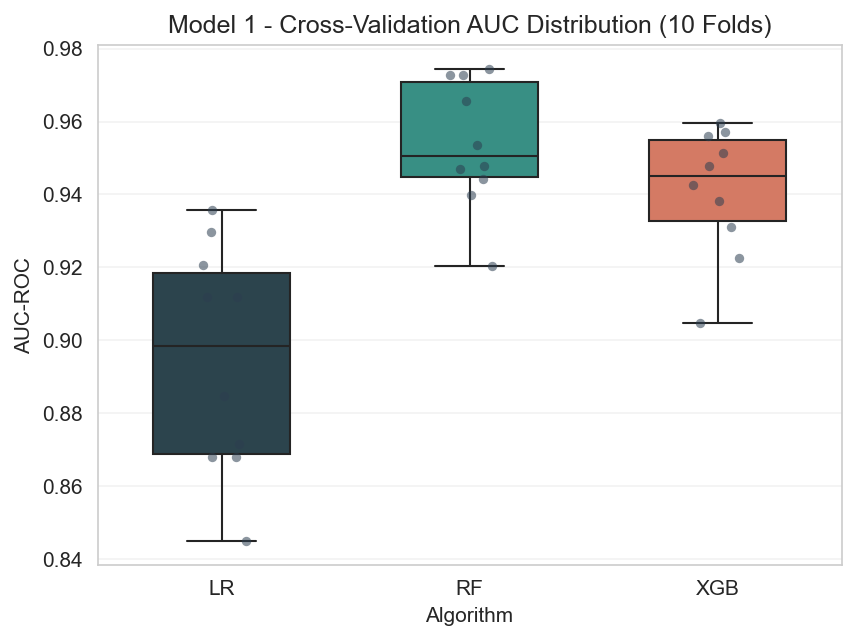

In [97]:
# Plotting the Model 1 cross-validation AUC distributions is showing variation across the ten folds rather than only the mean score.
m1_cv_auc_long = m1_cv_auc_df.melt(
    id_vars="fold",
    var_name="algorithm",
    value_name="auc"
)

fig, ax = plt.subplots(figsize=(6.4, 4.5))
sns.boxplot(
    data=m1_cv_auc_long,
    x="algorithm",
    y="auc",
    palette=[COLORS["lr"], COLORS["rf"], COLORS["xgb"]],
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=m1_cv_auc_long,
    x="algorithm",
    y="auc",
    color=COLORS["neutral"],
    alpha=0.55,
    size=4.5,
    ax=ax,
)
ax.set_title("Model 1 - Cross-Validation AUC Distribution (10 Folds)")
ax.set_xlabel("Algorithm")
ax.set_ylabel("AUC-ROC")
ax.grid(axis="y", alpha=0.25)

output_path = IMAGE_DIR / "09_model1_cv_score_distributions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [98]:
# Writing the cross-validation insight is explaining model stability in simple terms.
m1_cv_auc_stats = (
    m1_cv_auc_long
    .groupby("algorithm")["auc"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

best_cv_row = m1_cv_auc_stats.iloc[0]
most_stable_row = m1_cv_auc_stats.sort_values("std", ascending=True).iloc[0]

cv_markdown = "\n".join([
    "### Cross-Validation Insight",
    "",
    f"- The highest mean cross-validation AUC in Model 1 is coming from **{best_cv_row['algorithm']}** at **{best_cv_row['mean']:.4f}**.",
    f"- The most stable algorithm across folds in Model 1 is **{most_stable_row['algorithm']}** with a standard deviation of **{most_stable_row['std']:.4f}**.",
    "- A smaller spread means the model is behaving more consistently from fold to fold.",
    "",
    f"**Simple meaning:** This chart is not only showing which algorithm is strong, it is also showing which one is steady and repeatable across different training folds in Model 1.",
])
display(Markdown(cv_markdown))


### Cross-Validation Insight

- The highest mean cross-validation AUC in Model 1 is coming from **RF** at **0.9538**.
- The most stable algorithm across folds in Model 1 is **XGB** with a standard deviation of **0.0174**.
- A smaller spread means the model is behaving more consistently from fold to fold.

**Simple meaning:** This chart is not only showing which algorithm is strong, it is also showing which one is steady and repeatable across different training folds in Model 1.

## Section 6 - Model 2: All Three Algorithms

This section is repeating the same evaluation pattern on the invasive benchmark set so the non-invasive and invasive results can be compared fairly.


## Model 2: Logistic Regression

Logistic Regression is serving as the interpretable linear baseline for the invasive benchmark set. It is testing whether the hormonal and ultrasound features separate PCOS status in a simple linear way. If it performs strongly here, it suggests invasive markers may already carry clean directional signal.


In [99]:
# Defining and training Model 2 Logistic Regression is fitting the individual model on the locked training set from Notebook 07.
lr2 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    solver='lbfgs'
)
lr2.fit(X2_train, y2_train)
print("lr2 trained successfully.")


lr2 trained successfully.


In [100]:
# Running cross-validation for Model 2 Logistic Regression is estimating training stability with the locked 10-fold strategy.
cv_results_m2_lr = run_cv("Model 2 - Logistic Regression", lr2, X2_train, y2_train, cv)


Cross-validation summary - Model 2 - Logistic Regression
   metric   mean    std
 accuracy 0.8695 0.0343
precision 0.8662 0.0442
   recall 0.8763 0.0435
       f1 0.8704 0.0336
  roc_auc 0.9187 0.0411


In [101]:
# Evaluating Model 2 Logistic Regression on the hold-out test set is producing the final test metrics used in the comparison tables.
y2_pred_lr = lr2.predict(X2_test)
y2_proba_lr = lr2.predict_proba(X2_test)[:, 1]
results_m2_lr = evaluate_model("Model 2 - LR", lr2, X2_test, y2_test)

results_m2_lr_df = pd.DataFrame([results_m2_lr]).round(4)
print(results_m2_lr_df.to_string(index=False))


       model  accuracy  precision  recall     f1    auc
Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988


In [102]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m2_lr['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m2_lr['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m2_lr['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m2_lr['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m2_lr['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 Logistic Regression is giving a recall of **{results_m2_lr['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8349**. This is the share of all test cases the model got right.
- Precision: **0.7143**. This shows how often a positive prediction was actually correct.
- Recall: **0.8333**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7692**. This is the balance between precision and recall.
- AUC: **0.8988**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 Logistic Regression is giving a recall of **83.3%**, so it is catching about that share of PCOS-positive cases in the test set.

In [103]:
# Printing the confusion matrix table for Model 2 Logistic Regression is documenting the exact counts behind the heatmap.
cm_m2_lr = confusion_matrix(y2_test, y2_pred_lr)
cm_m2_lr_df = pd.DataFrame(
    cm_m2_lr,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 Logistic Regression:")
print(cm_m2_lr_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m2_lr[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m2_lr[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m2_lr[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m2_lr[0, 0]}")


Confusion Matrix - Model 2 Logistic Regression:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  61               12
Actual: PCOS                      6               30

True Positives  (caught PCOS cases) : 30
False Negatives (missed PCOS cases) : 6
False Positives (false alarms)      : 12
True Negatives  (correctly cleared) : 61


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\04_model2_lr_confusion_matrix.png


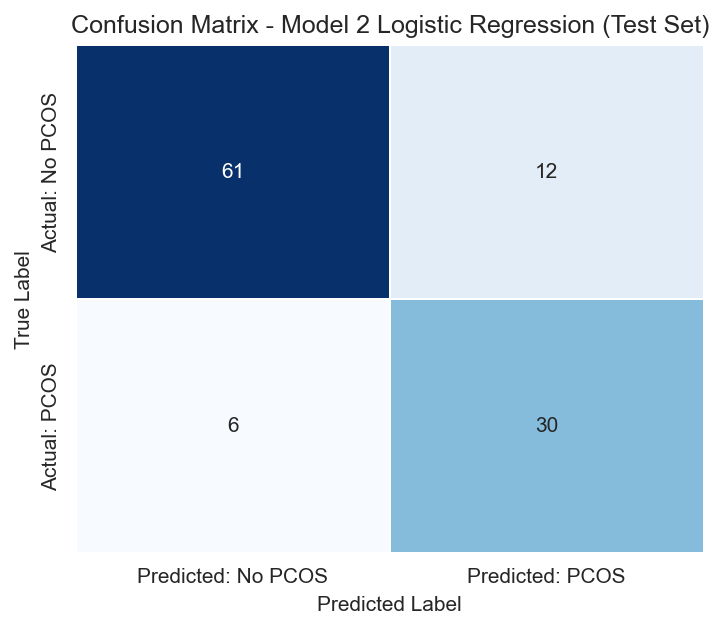

In [104]:
# Plotting the confusion matrix for Model 2 Logistic Regression is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m2_lr_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 Logistic Regression (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "04_model2_lr_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [105]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m2_lr[1, 1])
fn = int(cm_m2_lr[1, 0])
fp = int(cm_m2_lr[0, 1])
tn = int(cm_m2_lr[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 Logistic Regression, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **30**. These are PCOS cases the model caught correctly.
- False negatives: **6**. These are real PCOS cases the model missed.
- False positives: **12**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **61**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 2 Logistic Regression, the most important number to watch is the false-negative count of **6**, because missed PCOS cases matter more in a screening study.

In [106]:
# Saving Model 2 Logistic Regression is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model2_lr.pkl"
joblib.dump(lr2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_lr.pkl


## Model 2: Random Forest

Random Forest is testing whether the invasive benchmark features contain richer non-linear structure than the non-invasive model. Because the feature set includes hormonal and ultrasound markers, it may capture stronger branching patterns than the routine screening model.


In [107]:
# Defining and training Model 2 Random Forest is fitting the individual model on the locked training set from Notebook 07.
rf2 = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
rf2.fit(X2_train, y2_train)
print("rf2 trained successfully.")


rf2 trained successfully.


In [108]:
# Running cross-validation for Model 2 Random Forest is estimating training stability with the locked 10-fold strategy.
cv_results_m2_rf = run_cv("Model 2 - Random Forest", rf2, X2_train, y2_train, cv)


Cross-validation summary - Model 2 - Random Forest
   metric   mean    std
 accuracy 0.8798 0.0428
precision 0.8655 0.0433
   recall 0.9005 0.0570
       f1 0.8819 0.0421
  roc_auc 0.9450 0.0282


In [109]:
# Evaluating Model 2 Random Forest on the hold-out test set is producing the final test metrics used in the comparison tables.
y2_pred_rf = rf2.predict(X2_test)
y2_proba_rf = rf2.predict_proba(X2_test)[:, 1]
results_m2_rf = evaluate_model("Model 2 - RF", rf2, X2_test, y2_test)

results_m2_rf_df = pd.DataFrame([results_m2_rf]).round(4)
print(results_m2_rf_df.to_string(index=False))


       model  accuracy  precision  recall     f1    auc
Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955


In [110]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m2_rf['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m2_rf['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m2_rf['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m2_rf['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m2_rf['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 Random Forest is giving a recall of **{results_m2_rf['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8349**. This is the share of all test cases the model got right.
- Precision: **0.7500**. This shows how often a positive prediction was actually correct.
- Recall: **0.7500**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7500**. This is the balance between precision and recall.
- AUC: **0.8955**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 Random Forest is giving a recall of **75.0%**, so it is catching about that share of PCOS-positive cases in the test set.

In [111]:
# Printing the confusion matrix table for Model 2 Random Forest is documenting the exact counts behind the heatmap.
cm_m2_rf = confusion_matrix(y2_test, y2_pred_rf)
cm_m2_rf_df = pd.DataFrame(
    cm_m2_rf,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 Random Forest:")
print(cm_m2_rf_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m2_rf[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m2_rf[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m2_rf[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m2_rf[0, 0]}")


Confusion Matrix - Model 2 Random Forest:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  64                9
Actual: PCOS                      9               27

True Positives  (caught PCOS cases) : 27
False Negatives (missed PCOS cases) : 9
False Positives (false alarms)      : 9
True Negatives  (correctly cleared) : 64


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\05_model2_rf_confusion_matrix.png


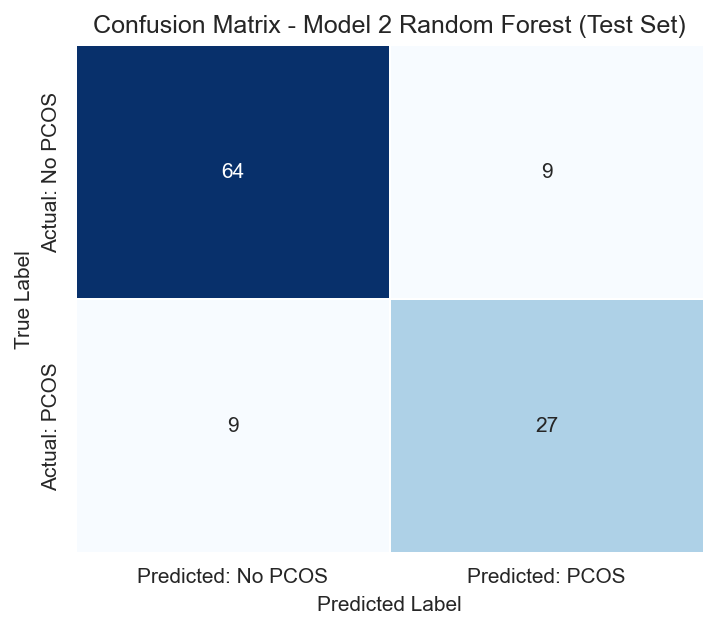

In [112]:
# Plotting the confusion matrix for Model 2 Random Forest is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m2_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 Random Forest (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "05_model2_rf_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [113]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m2_rf[1, 1])
fn = int(cm_m2_rf[1, 0])
fp = int(cm_m2_rf[0, 1])
tn = int(cm_m2_rf[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 Random Forest, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **27**. These are PCOS cases the model caught correctly.
- False negatives: **9**. These are real PCOS cases the model missed.
- False positives: **9**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **64**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 2 Random Forest, the most important number to watch is the false-negative count of **9**, because missed PCOS cases matter more in a screening study.

In [114]:
# Saving Model 2 Random Forest is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model2_rf.pkl"
joblib.dump(rf2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_rf.pkl


## Model 2: XGBoost

XGBoost is serving as the strongest expected learner on the invasive benchmark set. It is checking whether a boosted-tree approach can extract the most value from the hormonal and ultrasound features. This is important because the best invasive model becomes the main reference point for judging the cost of removing invasive tests.


In [115]:
# Computing scale_pos_weight is documenting the effective class weighting being passed into Model 2 XGBoost.
neg_count = int((y2_train == 0).sum())
pos_count = int((y2_train == 1).sum())
spw2 = neg_count / pos_count

print(f"Negative class count : {neg_count}")
print(f"Positive class count : {pos_count}")
print(f"scale_pos_weight     : {spw2:.4f}")
print("Note: the value is expected to be close to 1.0 because Notebook 07 already balanced the training set with SMOTE.")


Negative class count : 291
Positive class count : 291
scale_pos_weight     : 1.0000
Note: the value is expected to be close to 1.0 because Notebook 07 already balanced the training set with SMOTE.


In [116]:
# Defining and training Model 2 XGBoost is fitting the individual model on the locked training set from Notebook 07.
xgb2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw2,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb2.fit(X2_train, y2_train)
print("xgb2 trained successfully.")


xgb2 trained successfully.


In [117]:
# Running cross-validation for Model 2 XGBoost is estimating training stability with the locked 10-fold strategy.
cv_results_m2_xgb = run_cv("Model 2 - XGBoost", xgb2, X2_train, y2_train, cv)


Cross-validation summary - Model 2 - XGBoost
   metric   mean    std
 accuracy 0.8781 0.0530
precision 0.8773 0.0673
   recall 0.8832 0.0632
       f1 0.8787 0.0523
  roc_auc 0.9384 0.0268


In [118]:
# Evaluating Model 2 XGBoost on the hold-out test set is producing the final test metrics used in the comparison tables.
y2_pred_xgb = xgb2.predict(X2_test)
y2_proba_xgb = xgb2.predict_proba(X2_test)[:, 1]
results_m2_xgb = evaluate_model("Model 2 - XGB", xgb2, X2_test, y2_test)

results_m2_xgb_df = pd.DataFrame([results_m2_xgb]).round(4)
print(results_m2_xgb_df.to_string(index=False))


        model  accuracy  precision  recall     f1    auc
Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037


In [119]:
# Writing the simple metric insight is making the test-set numbers easier to explain in plain language.
metric_markdown = "\n".join([
    "### Simple Metric Reading",
    "",
    f"- Accuracy: **{results_m2_xgb['accuracy']:.4f}**. This is the share of all test cases the model got right.",
    f"- Precision: **{results_m2_xgb['precision']:.4f}**. This shows how often a positive prediction was actually correct.",
    f"- Recall: **{results_m2_xgb['recall']:.4f}**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.",
    f"- F1 score: **{results_m2_xgb['f1']:.4f}**. This is the balance between precision and recall.",
    f"- AUC: **{results_m2_xgb['auc']:.4f}**. This shows how well the model separates PCOS and non-PCOS cases overall.",
    "",
    f"**Simple meaning:** Model 2 XGBoost is giving a recall of **{results_m2_xgb['recall']*100:.1f}%**, so it is catching about that share of PCOS-positive cases in the test set.",
])
display(Markdown(metric_markdown))


### Simple Metric Reading

- Accuracy: **0.8624**. This is the share of all test cases the model got right.
- Precision: **0.8000**. This shows how often a positive prediction was actually correct.
- Recall: **0.7778**. This is the most important measure when missing a real PCOS case is costly, because it shows how many true PCOS cases were caught.
- F1 score: **0.7887**. This is the balance between precision and recall.
- AUC: **0.9037**. This shows how well the model separates PCOS and non-PCOS cases overall.

**Simple meaning:** Model 2 XGBoost is giving a recall of **77.8%**, so it is catching about that share of PCOS-positive cases in the test set.

In [120]:
# Printing the confusion matrix table for Model 2 XGBoost is documenting the exact counts behind the heatmap.
cm_m2_xgb = confusion_matrix(y2_test, y2_pred_xgb)
cm_m2_xgb_df = pd.DataFrame(
    cm_m2_xgb,
    index=["Actual: No PCOS", "Actual: PCOS"],
    columns=["Predicted: No PCOS", "Predicted: PCOS"],
)

print("Confusion Matrix - Model 2 XGBoost:")
print(cm_m2_xgb_df)
print()
print(f"True Positives  (caught PCOS cases) : {cm_m2_xgb[1, 1]}")
print(f"False Negatives (missed PCOS cases) : {cm_m2_xgb[1, 0]}")
print(f"False Positives (false alarms)      : {cm_m2_xgb[0, 1]}")
print(f"True Negatives  (correctly cleared) : {cm_m2_xgb[0, 0]}")


Confusion Matrix - Model 2 XGBoost:
                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                  66                7
Actual: PCOS                      8               28

True Positives  (caught PCOS cases) : 28
False Negatives (missed PCOS cases) : 8
False Positives (false alarms)      : 7
True Negatives  (correctly cleared) : 66


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\06_model2_xgb_confusion_matrix.png


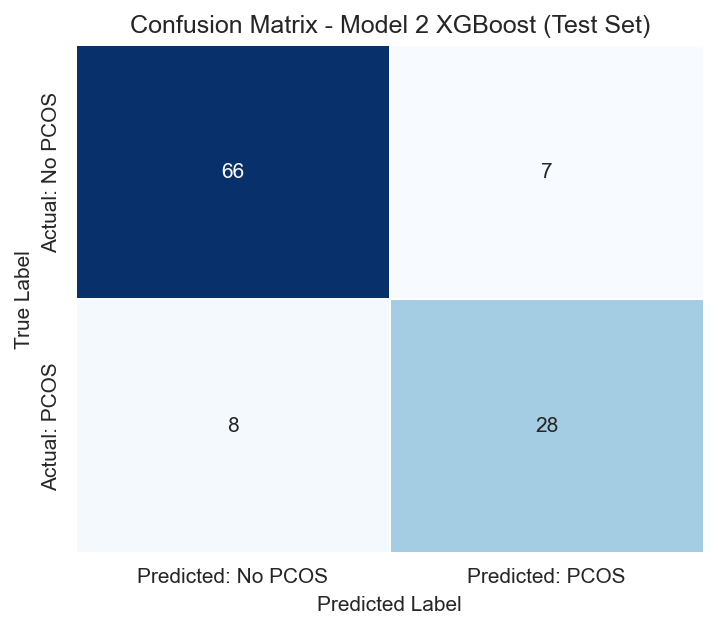

In [121]:
# Plotting the confusion matrix for Model 2 XGBoost is turning the printed count table into an easy visual summary.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(
    cm_m2_xgb_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix - Model 2 XGBoost (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

output_path = IMAGE_DIR / "06_model2_xgb_confusion_matrix.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [122]:
# Writing the confusion-matrix insight is explaining the most important error pattern in simple terms.
tp = int(cm_m2_xgb[1, 1])
fn = int(cm_m2_xgb[1, 0])
fp = int(cm_m2_xgb[0, 1])
tn = int(cm_m2_xgb[0, 0])

confusion_markdown = "\n".join([
    "### Confusion Matrix Insight",
    "",
    f"- True positives: **{tp}**. These are PCOS cases the model caught correctly.",
    f"- False negatives: **{fn}**. These are real PCOS cases the model missed.",
    f"- False positives: **{fp}**. These are false alarms where the model predicted PCOS but the patient was negative.",
    f"- True negatives: **{tn}**. These are non-PCOS cases the model cleared correctly.",
    "",
    f"**Simple meaning:** For Model 2 XGBoost, the most important number to watch is the false-negative count of **{fn}**, because missed PCOS cases matter more in a screening study.",
])
display(Markdown(confusion_markdown))


### Confusion Matrix Insight

- True positives: **28**. These are PCOS cases the model caught correctly.
- False negatives: **8**. These are real PCOS cases the model missed.
- False positives: **7**. These are false alarms where the model predicted PCOS but the patient was negative.
- True negatives: **66**. These are non-PCOS cases the model cleared correctly.

**Simple meaning:** For Model 2 XGBoost, the most important number to watch is the false-negative count of **8**, because missed PCOS cases matter more in a screening study.

In [123]:
# Saving Model 2 XGBoost is preserving the fitted model for later ensemble and explainability notebooks.
model_path = MODELS_DIR / "model2_xgb.pkl"
joblib.dump(xgb2, model_path)
print(f"Saved model to: {model_path}")


Saved model to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_xgb.pkl


## Model 2: Algorithm Comparison

This section is comparing the three individual algorithms inside Model 2 before moving to the next model set. The table and plots below are defining the single-model baseline for this feature contract.


In [124]:
# Printing the Model 2 comparison table is showing the final hold-out test metrics side by side.
m2_results = pd.DataFrame([results_m2_lr, results_m2_rf, results_m2_xgb])
m2_results["algorithm"] = ["LR", "RF", "XGB"]
m2_results = m2_results.set_index("model").round(4)

print("MODEL 2 - Algorithm Comparison (Test Set)")
print("=" * 70)
print(m2_results.to_string())
print()
print(f"Best Recall : {m2_results['recall'].idxmax()} ({m2_results['recall'].max():.4f})")
print(f"Best AUC    : {m2_results['auc'].idxmax()} ({m2_results['auc'].max():.4f})")
print(f"Best F1     : {m2_results['f1'].idxmax()} ({m2_results['f1'].max():.4f})")


MODEL 2 - Algorithm Comparison (Test Set)
               accuracy  precision  recall     f1    auc algorithm
model                                                             
Model 2 - LR     0.8349     0.7143  0.8333 0.7692 0.8988        LR
Model 2 - RF     0.8349     0.7500  0.7500 0.7500 0.8955        RF
Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037       XGB

Best Recall : Model 2 - LR (0.8333)
Best AUC    : Model 2 - XGB (0.9037)
Best F1     : Model 2 - XGB (0.7887)


In [125]:
# Writing the Model 2 comparison insight is turning the metric table into a simple summary.
best_auc_row = m2_results.reset_index().sort_values("auc", ascending=False).iloc[0]
best_recall_row = m2_results.reset_index().sort_values("recall", ascending=False).iloc[0]
best_f1_row = m2_results.reset_index().sort_values("f1", ascending=False).iloc[0]

comparison_markdown = "\n".join([
    "### Comparison Insight",
    "",
    f"- The best AUC in Model 2 is coming from **{best_auc_row['algorithm']}** at **{best_auc_row['auc']:.4f}**.",
    f"- The best recall in Model 2 is coming from **{best_recall_row['algorithm']}** at **{best_recall_row['recall']:.4f}**.",
    f"- The best F1 score in Model 2 is coming from **{best_f1_row['algorithm']}** at **{best_f1_row['f1']:.4f}**.",
    "",
    f"**Simple meaning:** Inside Model 2, this table is showing which algorithm is best at overall separation, which one catches the most PCOS cases, and which one gives the best balance between missing cases and raising false alarms.",
])
display(Markdown(comparison_markdown))


### Comparison Insight

- The best AUC in Model 2 is coming from **XGB** at **0.9037**.
- The best recall in Model 2 is coming from **LR** at **0.8333**.
- The best F1 score in Model 2 is coming from **XGB** at **0.7887**.

**Simple meaning:** Inside Model 2, this table is showing which algorithm is best at overall separation, which one catches the most PCOS cases, and which one gives the best balance between missing cases and raising false alarms.

In [126]:
# Printing the ROC summary table is documenting the exact AUC values used before plotting the Model 2 ROC curves.
m2_roc_table = (
    m2_results.reset_index()[["model", "algorithm", "auc"]]
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)
print(m2_roc_table.to_string(index=False))


        model algorithm    auc
Model 2 - XGB       XGB 0.9037
 Model 2 - LR        LR 0.8988
 Model 2 - RF        RF 0.8955


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\08_model2_roc_curves_all_algorithms.png


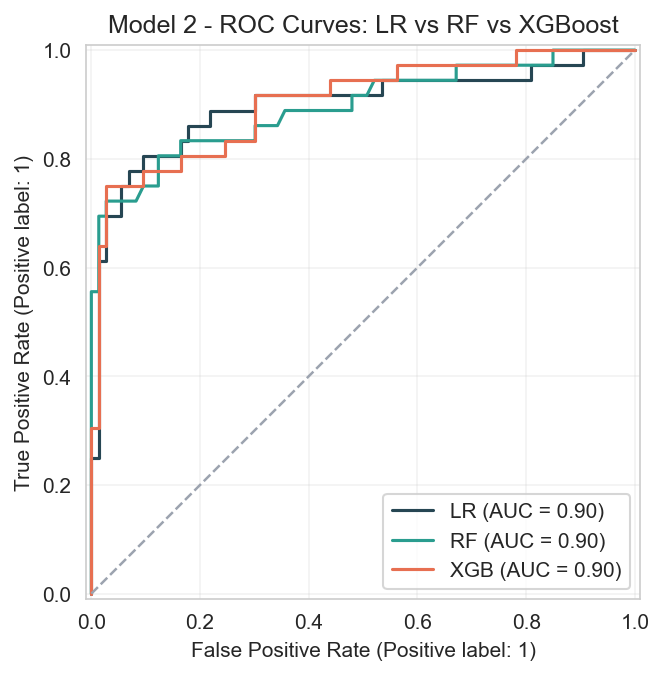

In [127]:
# Plotting the Model 2 ROC curves is comparing discrimination across the three individual algorithms on the same test set.
fig, ax = plt.subplots(figsize=(6.6, 4.8))
RocCurveDisplay.from_estimator(lr2, X2_test, y2_test, ax=ax, name="LR", color=COLORS["lr"])
RocCurveDisplay.from_estimator(rf2, X2_test, y2_test, ax=ax, name="RF", color=COLORS["rf"])
RocCurveDisplay.from_estimator(xgb2, X2_test, y2_test, ax=ax, name="XGB", color=COLORS["xgb"])
ax.plot([0, 1], [0, 1], linestyle="--", color="#9CA3AF", linewidth=1.2)
ax.set_title("Model 2 - ROC Curves: LR vs RF vs XGBoost")
ax.grid(alpha=0.25)

output_path = IMAGE_DIR / "08_model2_roc_curves_all_algorithms.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [128]:
# Writing the ROC insight is explaining what the curve comparison means in simple terms.
best_roc_row = m2_roc_table.iloc[0]
roc_markdown = "\n".join([
    "### ROC Insight",
    "",
    f"- The top ROC result in Model 2 is **{best_roc_row['algorithm']}** with an AUC of **{best_roc_row['auc']:.4f}**.",
    "- The curve that stays closer to the top-left corner is doing a better job of separating positive and negative cases.",
    "- The diagonal line is the no-skill line. A good model should stay above it.",
    "",
    f"**Simple meaning:** In Model 2, the algorithm with the highest AUC is giving the cleanest overall separation between PCOS and non-PCOS cases.",
])
display(Markdown(roc_markdown))


### ROC Insight

- The top ROC result in Model 2 is **XGB** with an AUC of **0.9037**.
- The curve that stays closer to the top-left corner is doing a better job of separating positive and negative cases.
- The diagonal line is the no-skill line. A good model should stay above it.

**Simple meaning:** In Model 2, the algorithm with the highest AUC is giving the cleanest overall separation between PCOS and non-PCOS cases.

In [129]:
# Printing the raw fold AUC table is documenting the exact cross-validation values used in the Model 2 CV distribution plot.
m2_cv_auc_df = pd.DataFrame({
    "fold": range(1, len(cv_results_m2_lr["fold_scores"]) + 1),
    "LR": cv_results_m2_lr["fold_scores"]["roc_auc"].values,
    "RF": cv_results_m2_rf["fold_scores"]["roc_auc"].values,
    "XGB": cv_results_m2_xgb["fold_scores"]["roc_auc"].values,
})
print(m2_cv_auc_df.to_string(index=False))


 fold     LR     RF    XGB
    1 0.8345 0.9115 0.9011
    2 0.9011 0.9500 0.9299
    3 0.8751 0.8942 0.9084
    4 0.9382 0.9839 0.9703
    5 0.9156 0.9429 0.9465
    6 0.9168 0.9275 0.9275
    7 0.9512 0.9394 0.9084
    8 0.9738 0.9602 0.9643
    9 0.9251 0.9750 0.9584
   10 0.9560 0.9655 0.9691


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\10_model2_cv_score_distributions.png


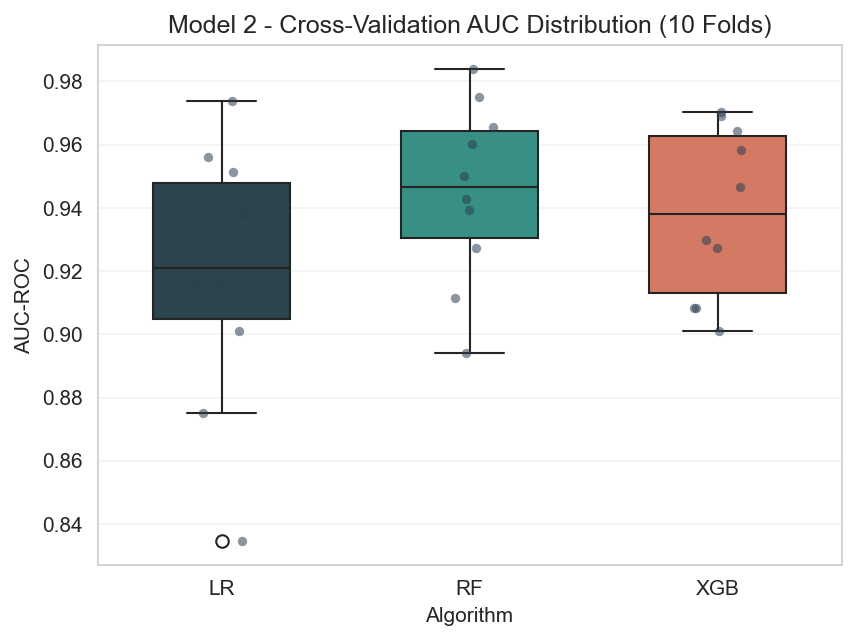

In [130]:
# Plotting the Model 2 cross-validation AUC distributions is showing variation across the ten folds rather than only the mean score.
m2_cv_auc_long = m2_cv_auc_df.melt(
    id_vars="fold",
    var_name="algorithm",
    value_name="auc"
)

fig, ax = plt.subplots(figsize=(6.4, 4.5))
sns.boxplot(
    data=m2_cv_auc_long,
    x="algorithm",
    y="auc",
    palette=[COLORS["lr"], COLORS["rf"], COLORS["xgb"]],
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=m2_cv_auc_long,
    x="algorithm",
    y="auc",
    color=COLORS["neutral"],
    alpha=0.55,
    size=4.5,
    ax=ax,
)
ax.set_title("Model 2 - Cross-Validation AUC Distribution (10 Folds)")
ax.set_xlabel("Algorithm")
ax.set_ylabel("AUC-ROC")
ax.grid(axis="y", alpha=0.25)

output_path = IMAGE_DIR / "10_model2_cv_score_distributions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()


In [131]:
# Writing the cross-validation insight is explaining model stability in simple terms.
m2_cv_auc_stats = (
    m2_cv_auc_long
    .groupby("algorithm")["auc"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

best_cv_row = m2_cv_auc_stats.iloc[0]
most_stable_row = m2_cv_auc_stats.sort_values("std", ascending=True).iloc[0]

cv_markdown = "\n".join([
    "### Cross-Validation Insight",
    "",
    f"- The highest mean cross-validation AUC in Model 2 is coming from **{best_cv_row['algorithm']}** at **{best_cv_row['mean']:.4f}**.",
    f"- The most stable algorithm across folds in Model 2 is **{most_stable_row['algorithm']}** with a standard deviation of **{most_stable_row['std']:.4f}**.",
    "- A smaller spread means the model is behaving more consistently from fold to fold.",
    "",
    f"**Simple meaning:** This chart is not only showing which algorithm is strong, it is also showing which one is steady and repeatable across different training folds in Model 2.",
])
display(Markdown(cv_markdown))


### Cross-Validation Insight

- The highest mean cross-validation AUC in Model 2 is coming from **RF** at **0.9450**.
- The most stable algorithm across folds in Model 2 is **XGB** with a standard deviation of **0.0268**.
- A smaller spread means the model is behaving more consistently from fold to fold.

**Simple meaning:** This chart is not only showing which algorithm is strong, it is also showing which one is steady and repeatable across different training folds in Model 2.

## Section 7 - Master Comparison: All Six Models

This section is combining the six individual results into one thesis-ready comparison table. It is answering two questions at once: which algorithm is best inside each model set, and how large the non-invasive versus invasive performance gap really is.


In [132]:
# Building the master results table is combining the six hold-out test results into one comparison frame.
all_results = pd.DataFrame([
    results_m1_lr, results_m1_rf, results_m1_xgb,
    results_m2_lr, results_m2_rf, results_m2_xgb,
])
all_results['model_set'] = ['Model 1', 'Model 1', 'Model 1', 'Model 2', 'Model 2', 'Model 2']
all_results['algorithm'] = ['LR', 'RF', 'XGB', 'LR', 'RF', 'XGB']
all_results = all_results.round(4)

print("MASTER RESULTS TABLE - All Six Individual Models")
print("=" * 80)
print(all_results.to_string(index=False))
print()

gap_rows = []
for algo in ['LR', 'RF', 'XGB']:
    m1_auc = all_results.loc[
        (all_results['algorithm'] == algo) & (all_results['model_set'] == 'Model 1'),
        'auc'
    ].iloc[0]
    m2_auc = all_results.loc[
        (all_results['algorithm'] == algo) & (all_results['model_set'] == 'Model 2'),
        'auc'
    ].iloc[0]
    gap = m2_auc - m1_auc
    gap_rows.append({
        'algorithm': algo,
        'model1_auc': round(m1_auc, 4),
        'model2_auc': round(m2_auc, 4),
        'absolute_gap': round(gap, 4),
        'percentage_point_gap': round(gap * 100, 2),
    })
    print(f"{algo}: Model 2 AUC = {m2_auc:.4f} | Model 1 AUC = {m1_auc:.4f} | Gap = {gap:.4f} ({gap*100:.2f}%)")

gap_df = pd.DataFrame(gap_rows)


MASTER RESULTS TABLE - All Six Individual Models
        model  accuracy  precision  recall     f1    auc model_set algorithm
 Model 1 - LR    0.8349     0.7368  0.7778 0.7568 0.8839   Model 1        LR
 Model 1 - RF    0.8532     0.8125  0.7222 0.7647 0.9098   Model 1        RF
Model 1 - XGB    0.8716     0.8438  0.7500 0.7941 0.9026   Model 1       XGB
 Model 2 - LR    0.8349     0.7143  0.8333 0.7692 0.8988   Model 2        LR
 Model 2 - RF    0.8349     0.7500  0.7500 0.7500 0.8955   Model 2        RF
Model 2 - XGB    0.8624     0.8000  0.7778 0.7887 0.9037   Model 2       XGB

LR: Model 2 AUC = 0.8988 | Model 1 AUC = 0.8839 | Gap = 0.0149 (1.49%)
RF: Model 2 AUC = 0.8955 | Model 1 AUC = 0.9098 | Gap = -0.0143 (-1.43%)
XGB: Model 2 AUC = 0.9037 | Model 1 AUC = 0.9026 | Gap = 0.0011 (0.11%)


In [133]:
# Saving the master results CSV is making the six-model comparison reusable in later notebooks and reporting.
output_path = MODELLING_DIR / 'individual_model_results.csv'
all_results.to_csv(output_path, index=False)
print(f"Saved results table to: {output_path}")


Saved results table to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\individual_model_results.csv


In [134]:
# Printing the heatmap input table is documenting the exact values used in the master performance heatmap.
master_heatmap_df = all_results.set_index(['model_set', 'algorithm'])[['accuracy', 'precision', 'recall', 'f1', 'auc']]
print(master_heatmap_df.to_string())


                     accuracy  precision  recall     f1    auc
model_set algorithm                                           
Model 1   LR           0.8349     0.7368  0.7778 0.7568 0.8839
          RF           0.8532     0.8125  0.7222 0.7647 0.9098
          XGB          0.8716     0.8438  0.7500 0.7941 0.9026
Model 2   LR           0.8349     0.7143  0.8333 0.7692 0.8988
          RF           0.8349     0.7500  0.7500 0.7500 0.8955
          XGB          0.8624     0.8000  0.7778 0.7887 0.9037


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\11_master_comparison_heatmap.png


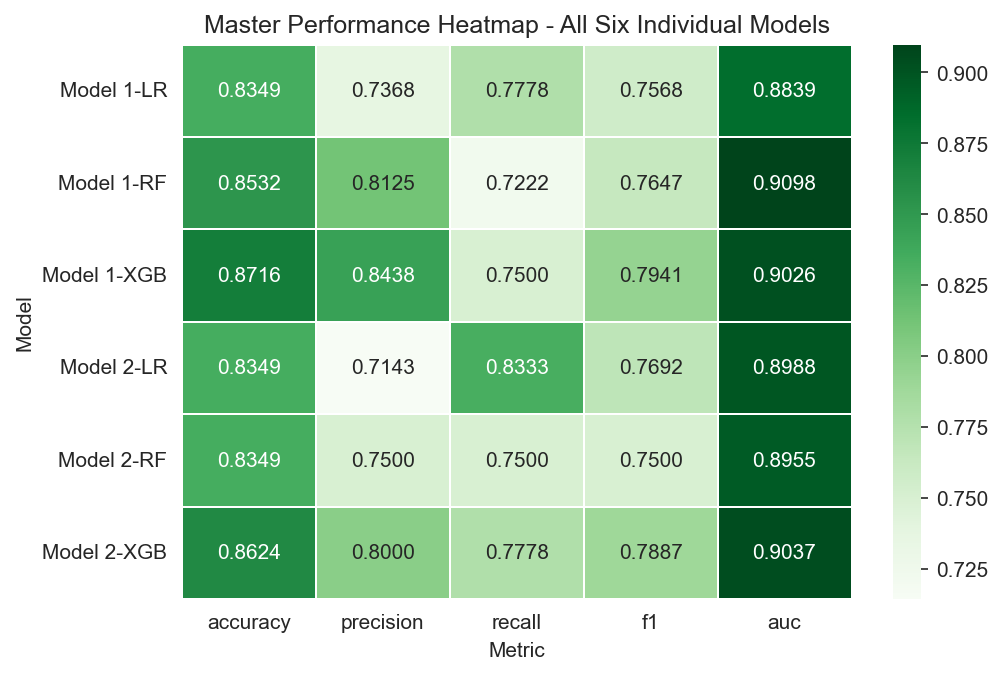

In [135]:
# Plotting the master comparison heatmap is showing the six-model metric profile in one compact view.
fig, ax = plt.subplots(figsize=(7.2, 4.8))
sns.heatmap(
    master_heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    linewidths=0.8,
    linecolor="white",
    cbar=True,
    ax=ax,
)
ax.set_title("Master Performance Heatmap - All Six Individual Models")
ax.set_xlabel("Metric")
ax.set_ylabel("Model")

output_path = IMAGE_DIR / '11_master_comparison_heatmap.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {output_path}")
plt.show()


In [136]:
# Writing the heatmap insight is turning the full metric grid into a simple message.
best_overall_auc = all_results.sort_values('auc', ascending=False).iloc[0]
heatmap_markdown = "\n".join([
    "### Heatmap Insight",
    "",
    f"- The best overall AUC in the full six-model table is **{best_overall_auc['model']}** at **{best_overall_auc['auc']:.4f}**.",
    "- Darker cells in the heatmap are showing stronger performance.",
    "- This chart is useful because it lets you compare all six models across all five metrics at once.",
    "",
    "**Simple meaning:** The heatmap is giving one quick picture of which model is strongest overall and where each model is weaker.",
])
display(Markdown(heatmap_markdown))


### Heatmap Insight

- The best overall AUC in the full six-model table is **Model 1 - RF** at **0.9098**.
- Darker cells in the heatmap are showing stronger performance.
- This chart is useful because it lets you compare all six models across all five metrics at once.

**Simple meaning:** The heatmap is giving one quick picture of which model is strongest overall and where each model is weaker.

In [137]:
# Printing the recall comparison table is documenting the exact values used in the recall bar chart.
recall_plot_df = all_results[['model_set', 'algorithm', 'recall']].copy().sort_values(['algorithm', 'model_set']).reset_index(drop=True)
print(recall_plot_df.to_string(index=False))


model_set algorithm  recall
  Model 1        LR  0.7778
  Model 2        LR  0.8333
  Model 1        RF  0.7222
  Model 2        RF  0.7500
  Model 1       XGB  0.7500
  Model 2       XGB  0.7778


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\12_recall_comparison_all_models.png


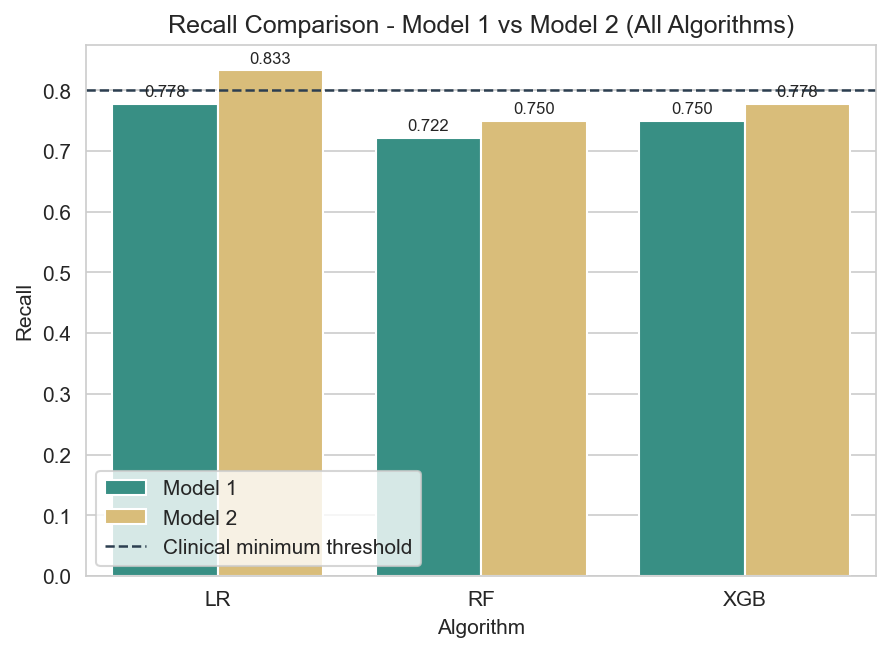

In [138]:
# Plotting the recall comparison is showing the practical case-detection difference between Model 1 and Model 2 across algorithms.
fig, ax = plt.subplots(figsize=(6.8, 4.6))
sns.barplot(
    data=recall_plot_df,
    x='algorithm',
    y='recall',
    hue='model_set',
    palette=[COLORS['model1'], COLORS['model2']],
    ax=ax,
)
ax.axhline(0.80, linestyle='--', color=COLORS['neutral'], linewidth=1.2, label='Clinical minimum threshold')
ax.set_title("Recall Comparison - Model 1 vs Model 2 (All Algorithms)")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Recall")
ax.legend(frameon=True)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

output_path = IMAGE_DIR / '12_recall_comparison_all_models.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {output_path}")
plt.show()


In [139]:
# Writing the recall insight is explaining the case-finding meaning of the bar chart.
best_recall_overall = recall_plot_df.sort_values('recall', ascending=False).iloc[0]
recall_markdown = "\n".join([
    "### Recall Insight",
    "",
    f"- The highest recall across all six models is **{best_recall_overall['algorithm']}** in **{best_recall_overall['model_set']}** at **{best_recall_overall['recall']:.4f}**.",
    "- Recall matters most when missing a real PCOS case is a serious problem.",
    "- A model with higher recall is catching more of the true PCOS cases.",
    "",
    "**Simple meaning:** This chart is showing which algorithm is best at finding PCOS cases instead of missing them.",
])
display(Markdown(recall_markdown))


### Recall Insight

- The highest recall across all six models is **LR** in **Model 2** at **0.8333**.
- Recall matters most when missing a real PCOS case is a serious problem.
- A model with higher recall is catching more of the true PCOS cases.

**Simple meaning:** This chart is showing which algorithm is best at finding PCOS cases instead of missing them.

In [140]:
# Printing the AUC comparison table is documenting the exact values used in the AUC bar chart.
auc_plot_df = all_results[['model_set', 'algorithm', 'auc']].copy().sort_values(['algorithm', 'model_set']).reset_index(drop=True)
print(auc_plot_df.to_string(index=False))


model_set algorithm    auc
  Model 1        LR 0.8839
  Model 2        LR 0.8988
  Model 1        RF 0.9098
  Model 2        RF 0.8955
  Model 1       XGB 0.9026
  Model 2       XGB 0.9037


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\13_auc_comparison_all_models.png


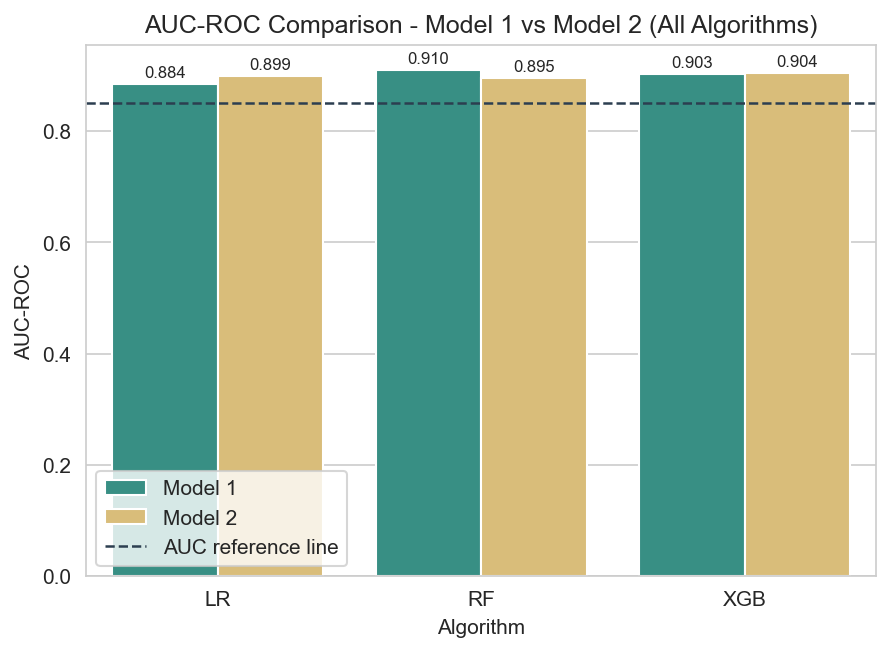

In [141]:
# Plotting the AUC comparison is showing how much discrimination changes between the non-invasive and invasive feature sets.
fig, ax = plt.subplots(figsize=(6.8, 4.6))
sns.barplot(
    data=auc_plot_df,
    x='algorithm',
    y='auc',
    hue='model_set',
    palette=[COLORS['model1'], COLORS['model2']],
    ax=ax,
)
ax.axhline(0.85, linestyle='--', color=COLORS['neutral'], linewidth=1.2, label='AUC reference line')
ax.set_title("AUC-ROC Comparison - Model 1 vs Model 2 (All Algorithms)")
ax.set_xlabel("Algorithm")
ax.set_ylabel("AUC-ROC")
ax.legend(frameon=True)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

output_path = IMAGE_DIR / '13_auc_comparison_all_models.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {output_path}")
plt.show()


In [142]:
# Writing the AUC insight is explaining the separation quality shown in the bar chart.
best_auc_overall = auc_plot_df.sort_values('auc', ascending=False).iloc[0]
auc_markdown = "\n".join([
    "### AUC Insight",
    "",
    f"- The highest AUC across all six models is **{best_auc_overall['algorithm']}** in **{best_auc_overall['model_set']}** at **{best_auc_overall['auc']:.4f}**.",
    "- A higher AUC means the model is doing a better job of separating PCOS and non-PCOS cases overall.",
    "- This chart is useful because it shows whether the invasive model gains a lot or only a little over the non-invasive model.",
    "",
    "**Simple meaning:** This chart is showing which model is best at overall separation, not just at one decision cutoff.",
])
display(Markdown(auc_markdown))


### AUC Insight

- The highest AUC across all six models is **RF** in **Model 1** at **0.9098**.
- A higher AUC means the model is doing a better job of separating PCOS and non-PCOS cases overall.
- This chart is useful because it shows whether the invasive model gains a lot or only a little over the non-invasive model.

**Simple meaning:** This chart is showing which model is best at overall separation, not just at one decision cutoff.

In [143]:
# Printing the performance-gap table is documenting the exact AUC difference values used in the gap chart.
print(gap_df.to_string(index=False))


algorithm  model1_auc  model2_auc  absolute_gap  percentage_point_gap
       LR      0.8839      0.8988        0.0149                1.4900
       RF      0.9098      0.8955       -0.0143               -1.4300
      XGB      0.9026      0.9037        0.0011                0.1100


Saved figure to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\14_model1_vs_model2_performance_gap.png


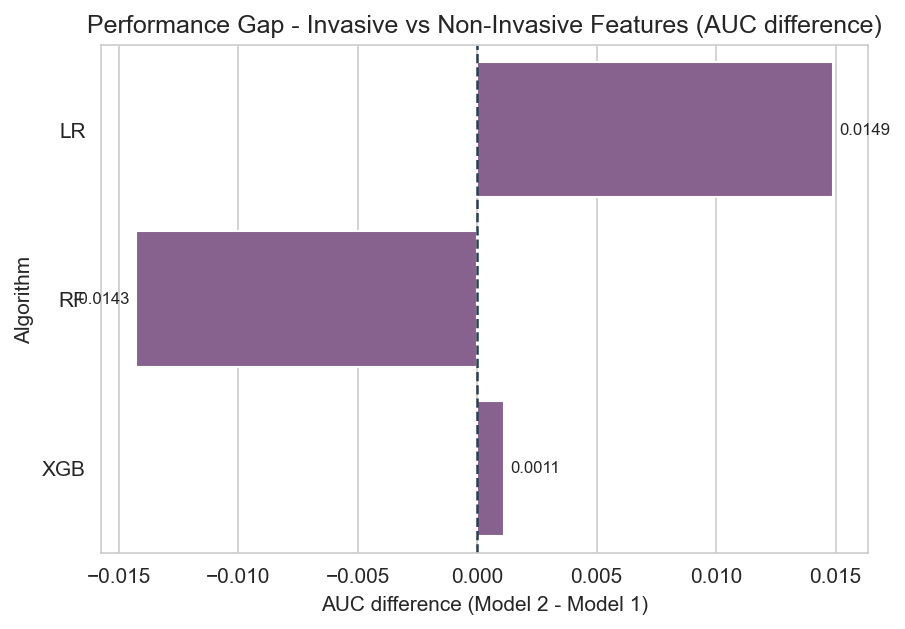

In [144]:
# Plotting the invasive-versus-non-invasive AUC gap is showing the cost of removing invasive features for each algorithm.
fig, ax = plt.subplots(figsize=(6.6, 4.4))
sns.barplot(
    data=gap_df,
    y='algorithm',
    x='absolute_gap',
    palette=[COLORS['highlight'], COLORS['highlight'], COLORS['highlight']],
    ax=ax,
)
ax.axvline(0, linestyle='--', color=COLORS['neutral'], linewidth=1.2)
ax.set_title("Performance Gap - Invasive vs Non-Invasive Features (AUC difference)")
ax.set_xlabel("AUC difference (Model 2 - Model 1)")
ax.set_ylabel("Algorithm")
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, padding=3)

output_path = IMAGE_DIR / '14_model1_vs_model2_performance_gap.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to: {output_path}")
plt.show()


In [145]:
# Writing the gap insight is explaining what is gained or lost when invasive features are added.
largest_gap = gap_df.sort_values('absolute_gap', ascending=False).iloc[0]
smallest_gap = gap_df.sort_values('absolute_gap', ascending=True).iloc[0]
gap_markdown = "\n".join([
    "### Performance Gap Insight",
    "",
    f"- The largest AUC gain from adding invasive features is seen in **{largest_gap['algorithm']}** at **{largest_gap['absolute_gap']:.4f}**.",
    f"- The smallest AUC gain from adding invasive features is seen in **{smallest_gap['algorithm']}** at **{smallest_gap['absolute_gap']:.4f}**.",
    "- A small gap means the non-invasive model is already close to the invasive benchmark.",
    "- A large gap means the invasive markers are adding more extra signal for that algorithm.",
    "",
    "**Simple meaning:** This chart is showing the price paid for removing invasive tests. Smaller bars are better for the screening model because they mean less performance was lost.",
])
display(Markdown(gap_markdown))


### Performance Gap Insight

- The largest AUC gain from adding invasive features is seen in **LR** at **0.0149**.
- The smallest AUC gain from adding invasive features is seen in **RF** at **-0.0143**.
- A small gap means the non-invasive model is already close to the invasive benchmark.
- A large gap means the invasive markers are adding more extra signal for that algorithm.

**Simple meaning:** This chart is showing the price paid for removing invasive tests. Smaller bars are better for the screening model because they mean less performance was lost.

## Key Findings from Individual Model Evaluation

This section is converting the six-model result table into thesis-ready interpretation that can be reused in Chapter 4.


In [146]:
# Building the key-findings markdown is turning the metric table into a clear written interpretation.
best_m1 = all_results.loc[all_results['model_set'] == 'Model 1'].sort_values(['auc', 'recall', 'f1'], ascending=False).iloc[0]
best_m2 = all_results.loc[all_results['model_set'] == 'Model 2'].sort_values(['auc', 'recall', 'f1'], ascending=False).iloc[0]

best_algo_gap = gap_df.sort_values('absolute_gap', ascending=False).iloc[0]
summary_markdown = "\n".join([
    "### Key Findings",
    "",
    f"**Paragraph 1:** Inside Model 1, the best-performing algorithm is **{best_m1['algorithm']}** with an AUC of **{best_m1['auc']:.4f}**, a recall of **{best_m1['recall']:.4f}**, and an F1 score of **{best_m1['f1']:.4f}**. This means the model is correctly identifying about **{best_m1['recall']*100:.1f}%** of PCOS-positive cases in the held-out test set.",
    "",
    f"**Paragraph 2:** Inside Model 2, the best-performing algorithm is **{best_m2['algorithm']}** with an AUC of **{best_m2['auc']:.4f}**, a recall of **{best_m2['recall']:.4f}**, and an F1 score of **{best_m2['f1']:.4f}**. This is acting as the invasive benchmark for the current stage of the thesis.",
    "",
    f"**Paragraph 3:** The biggest invasive-versus-non-invasive AUC difference is currently seen in **{best_algo_gap['algorithm']}**, where the invasive model exceeds the non-invasive model by **{best_algo_gap['absolute_gap']:.4f}** AUC points, or **{best_algo_gap['percentage_point_gap']:.2f} percentage points**. This is quantifying the price paid for removing invasive tests.",
    "",
    "**Paragraph 4:** These results are setting the baseline for Notebook 09. The strongest individual learner in each model set becomes the main reference point for the later stacking notebook, and the current gaps define the improvement target for later ensemble and optimization steps.",
])
display(Markdown(summary_markdown))


### Key Findings

**Paragraph 1:** Inside Model 1, the best-performing algorithm is **RF** with an AUC of **0.9098**, a recall of **0.7222**, and an F1 score of **0.7647**. This means the model is correctly identifying about **72.2%** of PCOS-positive cases in the held-out test set.

**Paragraph 2:** Inside Model 2, the best-performing algorithm is **XGB** with an AUC of **0.9037**, a recall of **0.7778**, and an F1 score of **0.7887**. This is acting as the invasive benchmark for the current stage of the thesis.

**Paragraph 3:** The biggest invasive-versus-non-invasive AUC difference is currently seen in **LR**, where the invasive model exceeds the non-invasive model by **0.0149** AUC points, or **1.49 percentage points**. This is quantifying the price paid for removing invasive tests.

**Paragraph 4:** These results are setting the baseline for Notebook 09. The strongest individual learner in each model set becomes the main reference point for the later stacking notebook, and the current gaps define the improvement target for later ensemble and optimization steps.

In [147]:
# Verifying the final output files is checking that every saved artifact exists and is non-empty.
required_files = [
    MODELS_DIR / 'model1_lr.pkl',
    MODELS_DIR / 'model1_rf.pkl',
    MODELS_DIR / 'model1_xgb.pkl',
    MODELS_DIR / 'model2_lr.pkl',
    MODELS_DIR / 'model2_rf.pkl',
    MODELS_DIR / 'model2_xgb.pkl',
    MODELLING_DIR / 'individual_model_results.csv',
    IMAGE_DIR / '01_model1_lr_confusion_matrix.png',
    IMAGE_DIR / '02_model1_rf_confusion_matrix.png',
    IMAGE_DIR / '03_model1_xgb_confusion_matrix.png',
    IMAGE_DIR / '04_model2_lr_confusion_matrix.png',
    IMAGE_DIR / '05_model2_rf_confusion_matrix.png',
    IMAGE_DIR / '06_model2_xgb_confusion_matrix.png',
    IMAGE_DIR / '07_model1_roc_curves_all_algorithms.png',
    IMAGE_DIR / '08_model2_roc_curves_all_algorithms.png',
    IMAGE_DIR / '09_model1_cv_score_distributions.png',
    IMAGE_DIR / '10_model2_cv_score_distributions.png',
    IMAGE_DIR / '11_master_comparison_heatmap.png',
    IMAGE_DIR / '12_recall_comparison_all_models.png',
    IMAGE_DIR / '13_auc_comparison_all_models.png',
    IMAGE_DIR / '14_model1_vs_model2_performance_gap.png',
]

all_passed = True
for file_path in required_files:
    exists = file_path.exists()
    non_empty = exists and file_path.stat().st_size > 0
    status = 'PASS' if exists and non_empty else 'FAIL'
    if status == 'FAIL':
        all_passed = False
    print(f"[{status}] {file_path}")

print()
if all_passed:
    print("All output files verified successfully and are non-empty.")
else:
    print("WARNING: Some output files are missing or empty. Check the cells above.")


[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_lr.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_rf.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model1_xgb.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_lr.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_rf.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\models\model2_xgb.pkl
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\individual_model_results.csv
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\01_model1_lr_confusion_matrix.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\02_model1_rf_confusion_matrix.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\individual_models\03

## Notebook Summary and Next Steps

This section is closing the individual-model notebook and pointing forward to the stacking notebook.


In [148]:
# Building the closing summary markdown is turning the final outputs into a clean bridge to Notebook 09.
best_model1_name = best_m1['model']
best_model2_name = best_m2['model']
closing_markdown = "\n".join([
    "### Notebook Summary",
    "",
    "This notebook has trained and saved six individual models:",
    "- `models/model1_lr.pkl`",
    "- `models/model1_rf.pkl`",
    "- `models/model1_xgb.pkl`",
    "- `models/model2_lr.pkl`",
    "- `models/model2_rf.pkl`",
    "- `models/model2_xgb.pkl`",
    "",
    "The full six-model comparison table has been saved to `cleaned_data/modelling_sets/individual_model_results.csv`.",
    "",
    f"The current best Model 1 algorithm is **{best_model1_name}**. The current best Model 2 algorithm is **{best_model2_name}**. The invasive-versus-non-invasive gap measured here is defining the improvement target for the next stage.",
    "",
    "Notebook 09 will build the stacking ensemble for each model set by combining the saved base learners with a meta-learner. It will then test whether stacking improves on the best individual algorithm from this notebook.",
])
display(Markdown(closing_markdown))


### Notebook Summary

This notebook has trained and saved six individual models:
- `models/model1_lr.pkl`
- `models/model1_rf.pkl`
- `models/model1_xgb.pkl`
- `models/model2_lr.pkl`
- `models/model2_rf.pkl`
- `models/model2_xgb.pkl`

The full six-model comparison table has been saved to `cleaned_data/modelling_sets/individual_model_results.csv`.

The current best Model 1 algorithm is **Model 1 - RF**. The current best Model 2 algorithm is **Model 2 - XGB**. The invasive-versus-non-invasive gap measured here is defining the improvement target for the next stage.

Notebook 09 will build the stacking ensemble for each model set by combining the saved base learners with a meta-learner. It will then test whether stacking improves on the best individual algorithm from this notebook.